In [38]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import plot_model
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import tensorflow as tf
import pandas as pd
import numpy as np
import cv2
import os

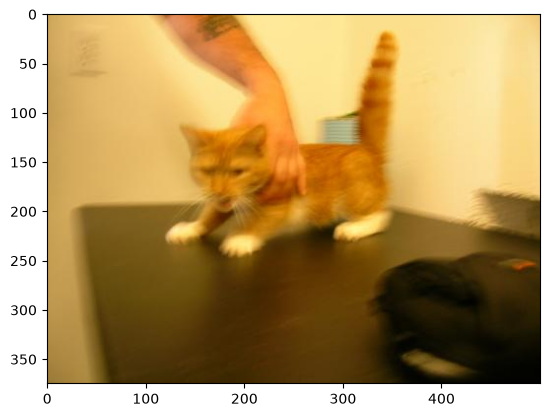

In [39]:
img = image.load_img('Dataset/train/Cat/cat (1).jpg')
plt.imshow(img)

In [40]:
cv2.imread('Dataset/train/Cat/cat (1).jpg').shape #height, width, and channels of image

(375, 500, 3)

In [41]:
train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
validation = ImageDataGenerator(rescale=1/255)

In [42]:
train_dataset = train.flow_from_directory('Dataset/train/',
                                           target_size= (200,200),
                                           classes=['cat', 'cow', 'dog', 'elephant', 'sheep'],
                                           batch_size= 10,
                                           class_mode='categorical')

validation_dataset = validation.flow_from_directory('Dataset/validation/',
                                           target_size= (200,200),
                                           classes=['cat', 'cow', 'dog', 'elephant', 'sheep'],
                                           batch_size= 10,
                                           class_mode='categorical') # use categorical because have multiple classes : Cat, Cow, Dog, Elephant, and Sheep

Found 900 images belonging to 5 classes.
Found 50 images belonging to 5 classes.


In [43]:
model = tf.keras.models.Sequential([tf.keras.layers.Conv2D(16,(3,3),activation = 'relu', input_shape = (200,200,3)),
                                    tf.keras.layers.MaxPooling2D(2,2),
                                    
                                    tf.keras.layers.Conv2D(32,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPooling2D(2,2),
                                    
                                    tf.keras.layers.Conv2D(64,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPooling2D(2,2),
                                    
                                    tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(512, activation='relu'),
                                    tf.keras.layers.Dense(1, activation='sigmoid')
                                    
                                   ])

c:\Users\PC Care\Downloads\IAIML_Y3_prediction_image\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.compile(loss='categorical_crossentropy',
              optimizer= 'adam',
              metrics=['accuracy'])

In [45]:
import tensorflow as tf

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(200, 200, 3)),
    
    # Convolutional & Pooling layers
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.MaxPool2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPool2D(2, 2),
    
    # Flatten features into 1D
    tf.keras.layers.Flatten(),
    
    # Fully connected dense layer
    tf.keras.layers.Dense(512, activation='relu'),
    
    # --- ADD DROPOUT HERE ---
    tf.keras.layers.Dropout(0.5),  # Drops 50% of random neurons during training to prevent memorization
    
    # Final Output Layer (5 animal classes)
    tf.keras.layers.Dense(5, activation='softmax')
])

In [46]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Categorical crossentropy for 5 classes
    metrics=['accuracy']
)

In [47]:
import tensorflow as tf

# Load pre-trained MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(200, 200, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base layers

# Build new head
model = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(5, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

C:\Users\PC Care\AppData\Local\Temp\ipykernel_11716\1810823802.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step


In [48]:
model_fit = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[tf.keras.callbacks.CSVLogger('history.csv')],
    shuffle=True
)

# Pass validation_dataset instead of train_dataset
_, accuracy = model.evaluate(validation_dataset)
print(f"Real Validation Accuracy: {round(accuracy * 100, 2)}%")

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 40s 370ms/step - accuracy: 0.6878 - loss: 0.8643 - val_accuracy: 0.8800 - val_loss: 0.3132
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 32s 352ms/step - accuracy: 0.8989 - loss: 0.3050 - val_accuracy: 0.9200 - val_loss: 0.2355
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 32s 351ms/step - accuracy: 0.9389 - loss: 0.2199 - val_accuracy: 0.9400 - val_loss: 0.1916
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 31s 339ms/step - accuracy: 0.9444 - loss: 0.1908 - val_accuracy: 0.9600 - val_loss: 0.1650
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 31s 341ms/step - accuracy: 0.9556 - loss: 0.1406 - val_accuracy: 0.9600 - val_loss: 0.1252
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 32s 353ms/step - accuracy: 0.9522 - loss: 0.1400 - val_accuracy: 0.9400 - val_loss: 0.1731
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 32s 355ms/step - accuracy: 0.9511 - loss: 0.1244 - val_accuracy: 0.9400 - val_loss: 0.1265
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 33s 365ms/step - accuracy: 0.9667 - loss: 0.1204 - val_accu

In [49]:
import pandas as pd

his = pd.read_csv('history.csv') 
his.head(10)

,epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.687778,0.864271,0.88,0.313227
1,1,0.898889,0.304998,0.92,0.235467
2,2,0.938889,0.219869,0.94,0.191619
3,3,0.944444,0.190758,0.96,0.164977
4,4,0.955556,0.140621,0.96,0.125185
5,5,0.952222,0.140042,0.94,0.173105
6,6,0.951111,0.124402,0.94,0.126470
7,7,0.966667,0.120435,0.96,0.129652
8,8,0.955556,0.132979,0.94,0.133552
9,9,0.973333,0.089968,0.94,0.109342


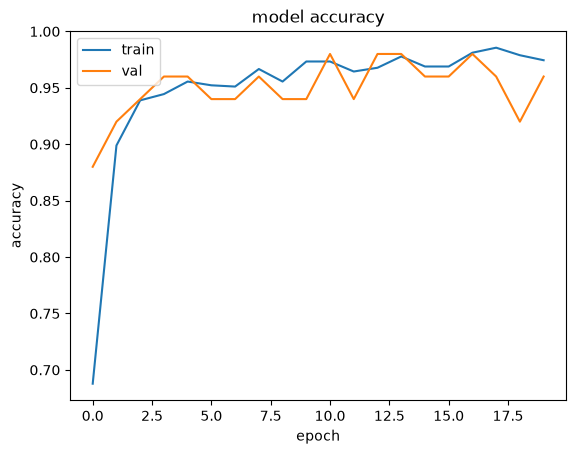

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

# Load training logs from CSV
his = pd.read_csv('history.csv')

plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

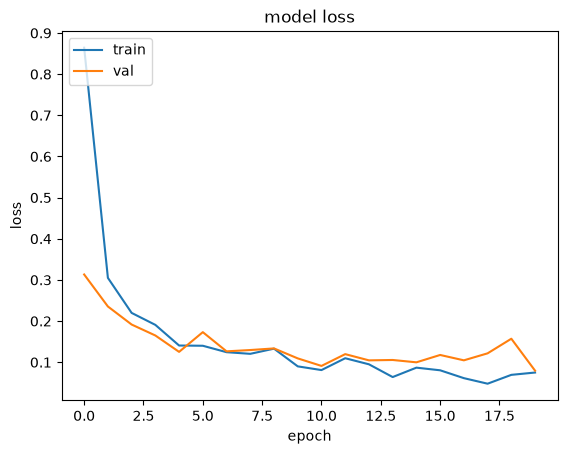

In [51]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [52]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Add traces
fig.add_trace(
    go.Scatter( y=model_fit.history['val_loss'], name="val_loss"),
    secondary_y=False)

fig.add_trace(
    go.Scatter( y=model_fit.history['loss'], name="loss"),
    secondary_y=False)

fig.add_trace(
    go.Scatter( y=model_fit.history['val_accuracy'], name="val_accuracy"),
    secondary_y=True)

fig.add_trace(
    go.Scatter( y=model_fit.history['accuracy'], name="accuracy"),
    secondary_y=True)

# Add figure title
fig.update_layout(
    title_text="Loss/Accuracy of Conv2D Model")

# Set x-axis title
fig.update_xaxes(title_text="Number of Epochs")

# Set y-axes titles
fig.update_yaxes(title_text="<b>primary</b> Loss", secondary_y=False)
fig.update_yaxes(title_text="<b>secondary</b> Accuracy", secondary_y=True)

fig.show()

In [53]:
model.summary() #Detail of model

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,277,201 (8.69 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 12,812 (50.05 KB)

In [61]:
plot_model(model, to_file = 'convlstm_model_structure_plot.png', show_shapes = True, show_layer_names = True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [62]:
# Check models first to see if file exists already.
# If not, the model is saved to disk.
if os.path.isfile('models/CNN_predict_model.h5') is False:
    model.save('models/CNN_predict_model.h5')

In [63]:
validation_dataset.class_indices

{'cat': 0, 'cow': 1, 'dog': 2, 'elephant': 3, 'sheep': 4}

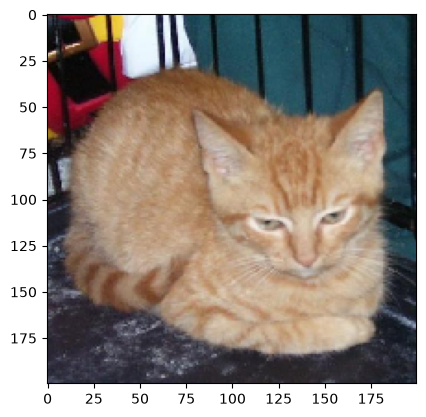

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cat 🐈


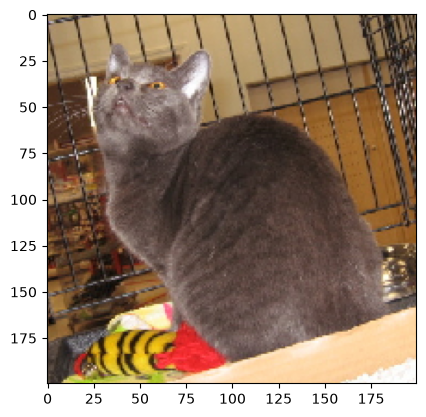

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cat 🐈


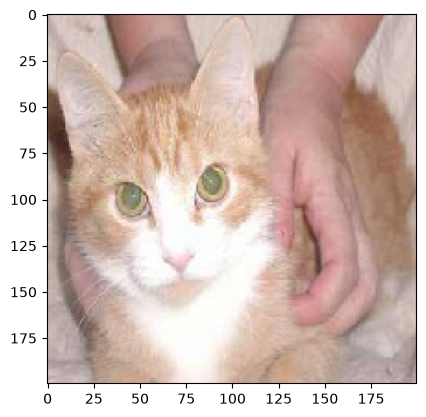

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cat 🐈


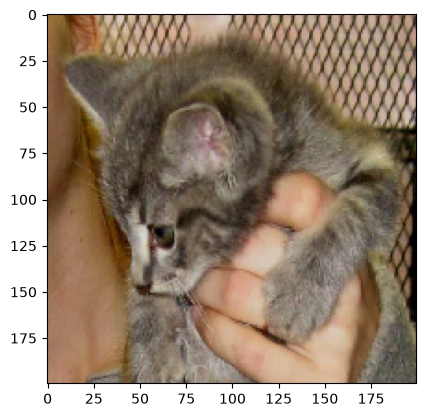

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cat 🐈


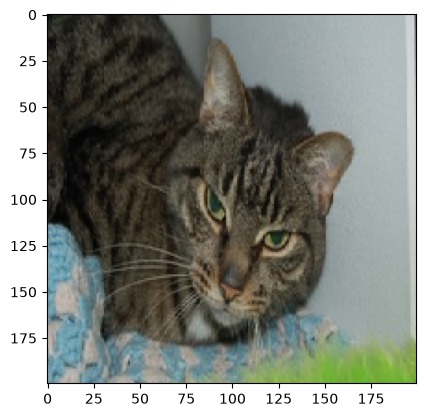

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cat 🐈


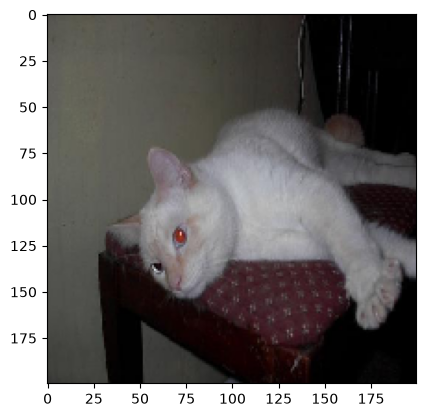

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cat 🐈


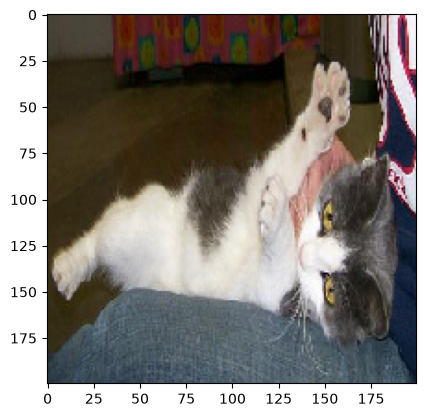

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cat 🐈


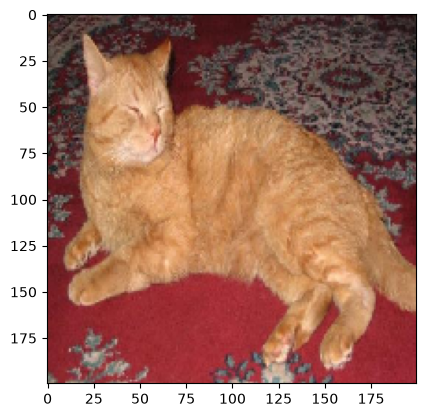

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cat 🐈


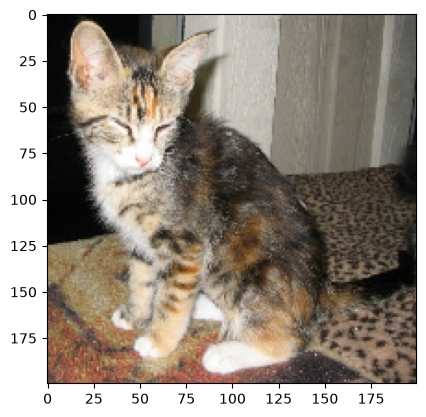

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cat 🐈


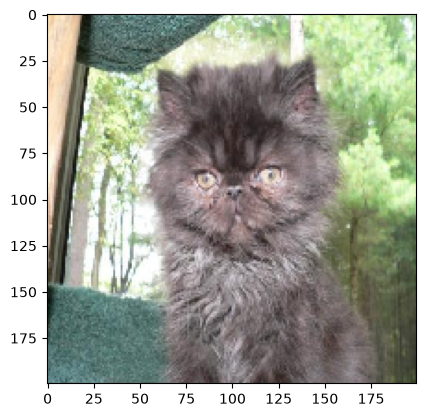

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cat 🐈


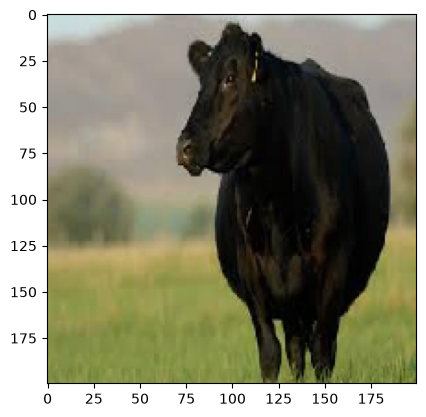

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cow 🐄


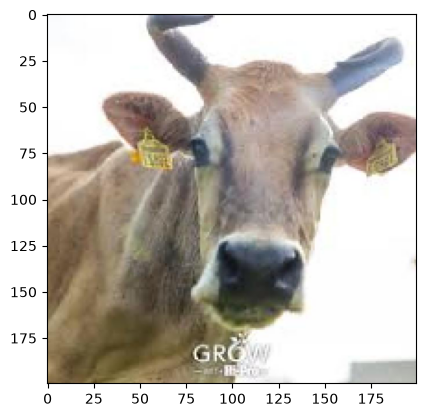

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cow 🐄


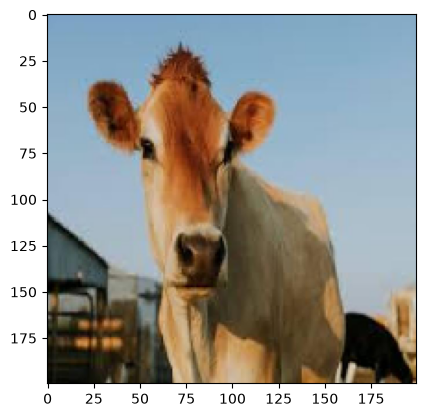

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cow 🐄


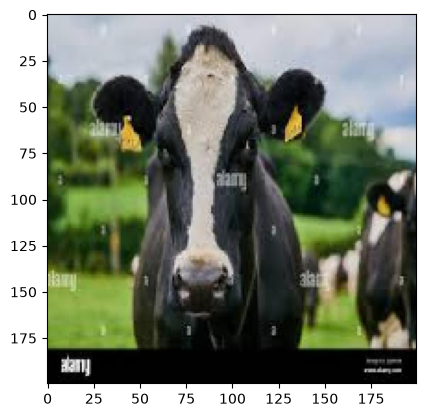

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cow 🐄


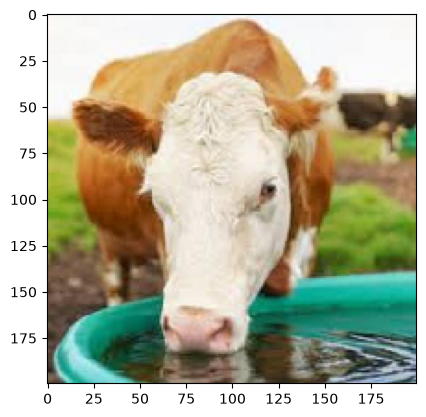

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cow 🐄


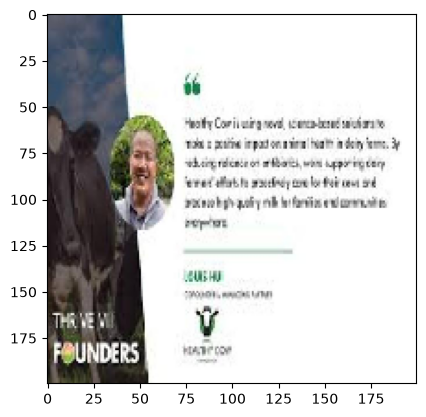

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cow 🐄


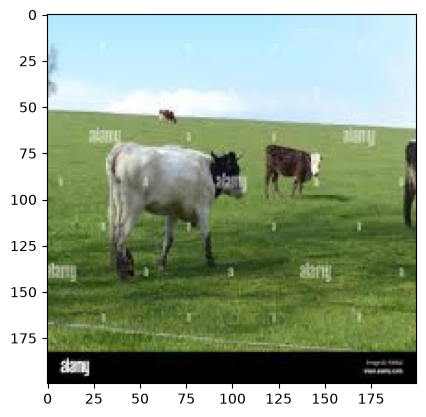

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Cow 🐄


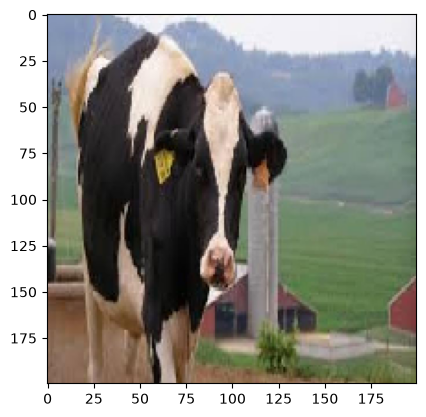

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This is a: Cow 🐄


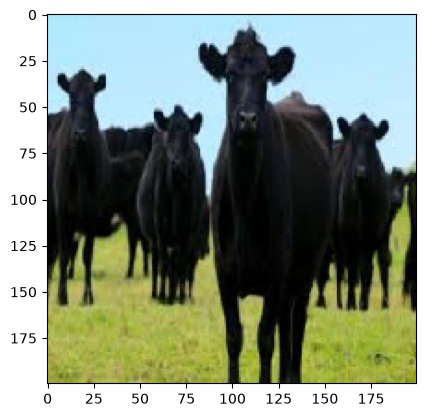

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This is a: Cow 🐄


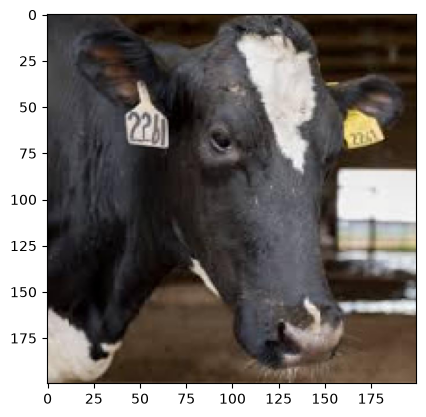

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This is a: Cow 🐄


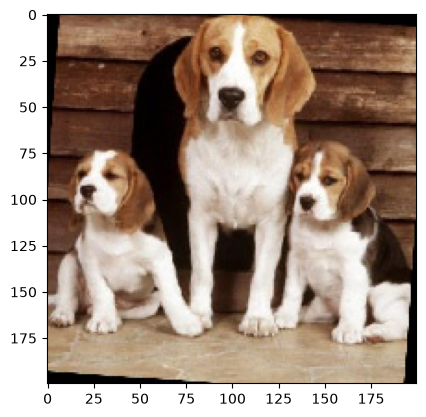

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This is a: Dog 🐶


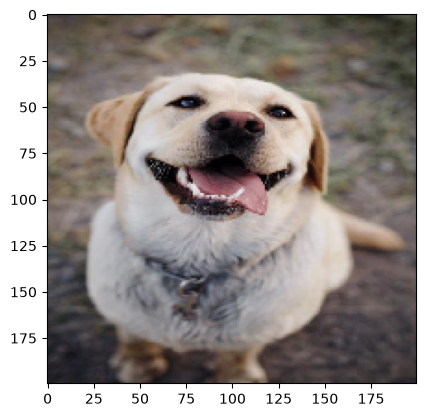

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This is a: Dog 🐶


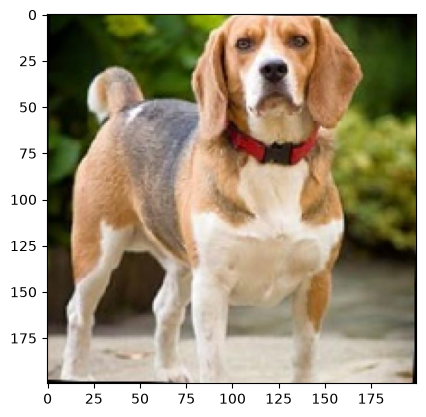

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This is a: Dog 🐶


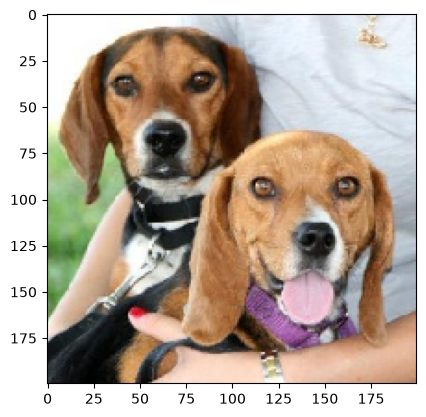

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
This is a: Dog 🐶


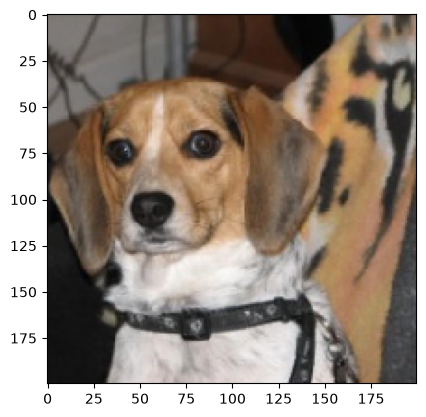

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
This is a: Dog 🐶


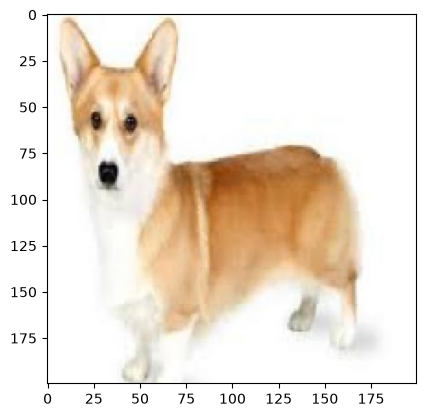

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This is a: Dog 🐶


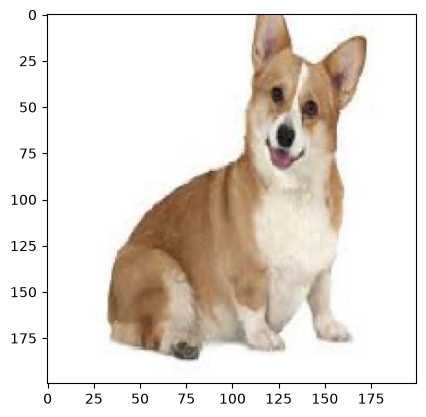

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This is a: Dog 🐶


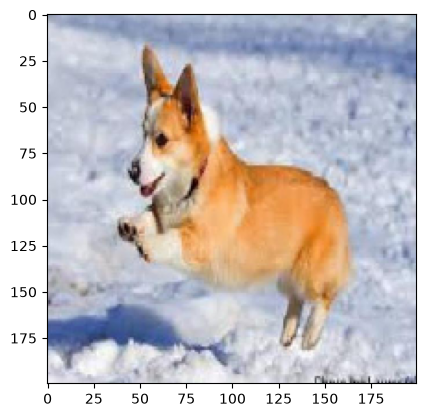

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This is a: Dog 🐶


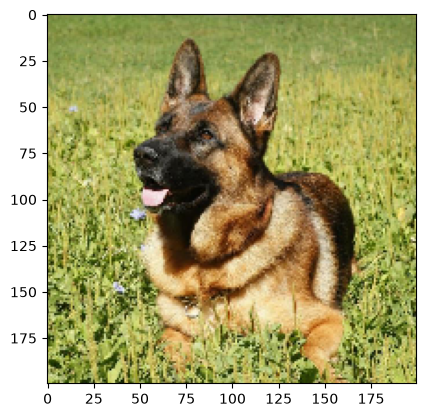

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
This is a: Dog 🐶


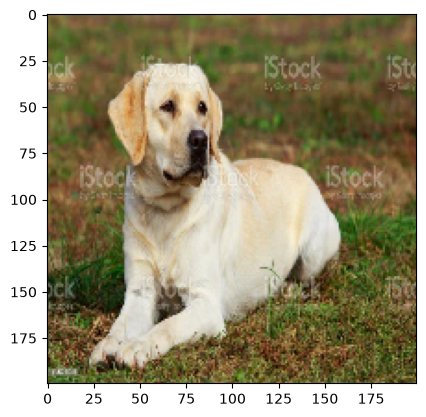

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This is a: Dog 🐶


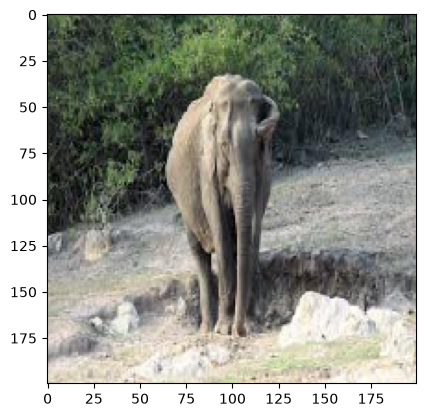

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This is a: Elephant 🐘


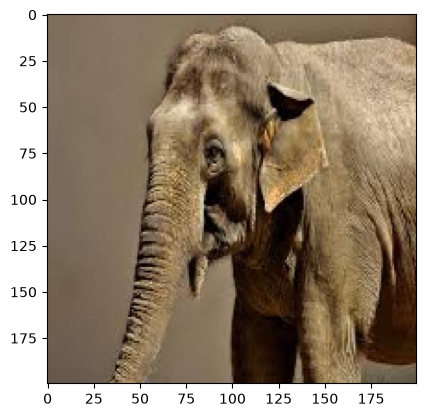

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This is a: Elephant 🐘


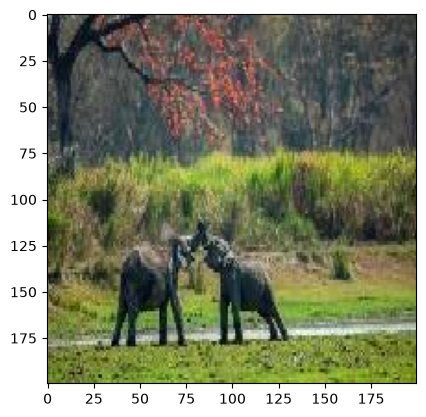

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This is a: Elephant 🐘


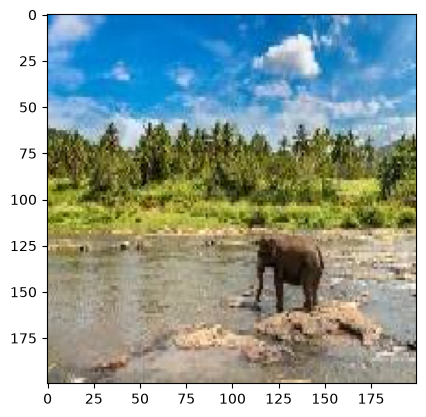

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Elephant 🐘


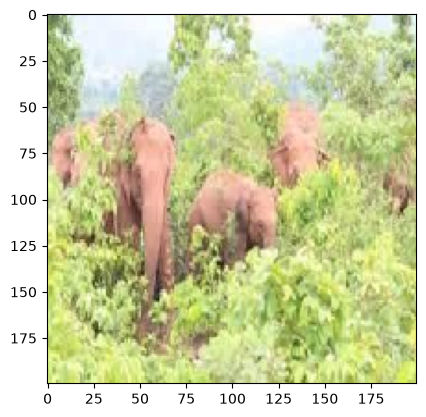

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Elephant 🐘


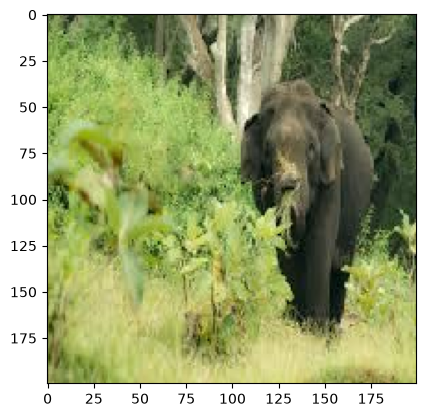

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Elephant 🐘


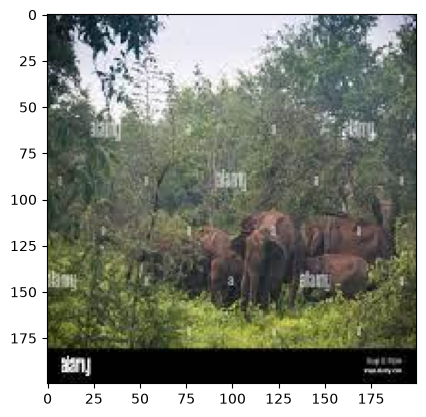

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
This is a: Elephant 🐘


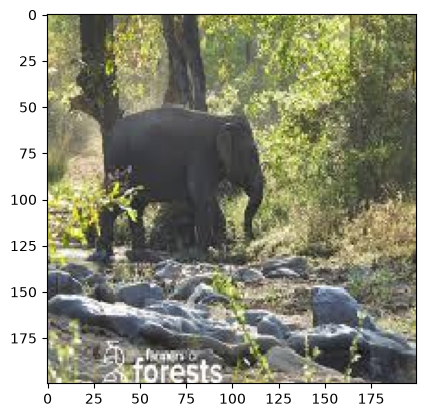

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This is a: Elephant 🐘


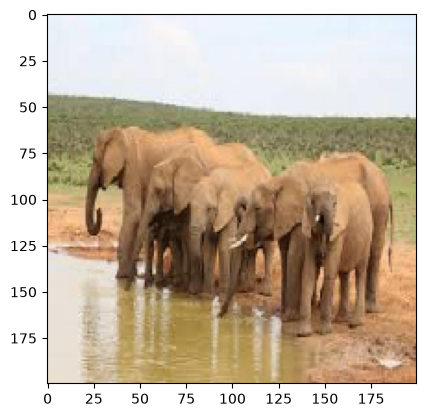

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
This is a: Elephant 🐘


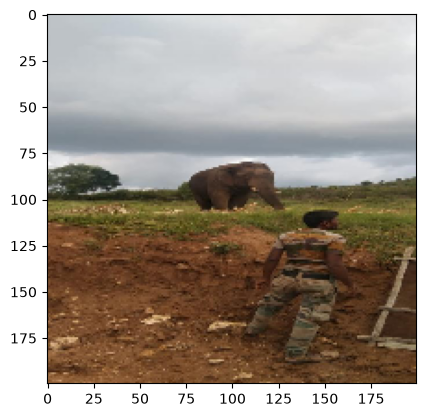

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
This is a: Elephant 🐘


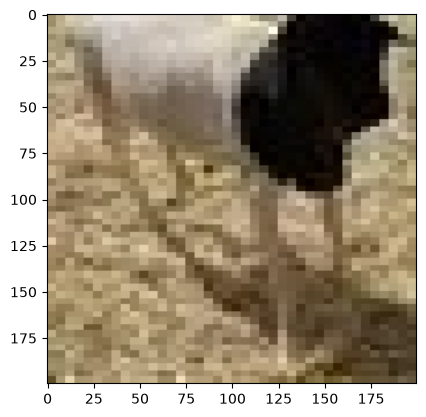

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
This is a: Sheep 🐑


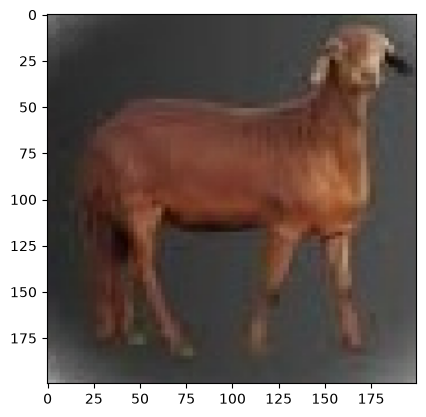

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
This is a: Sheep 🐑


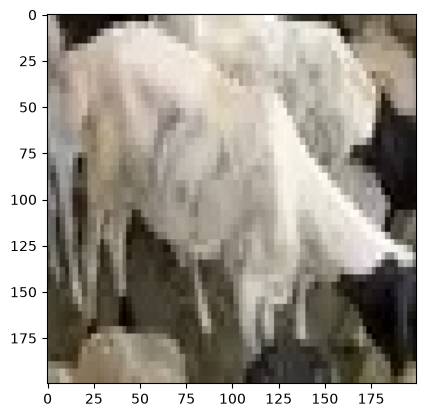

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
This is a: Sheep 🐑


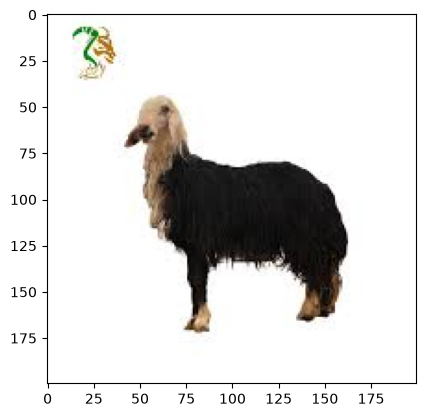

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This is a: Sheep 🐑


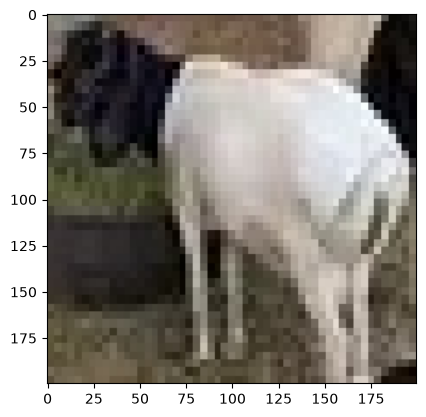

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
This is a: Sheep 🐑


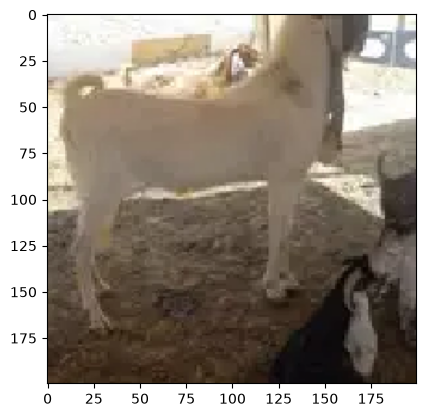

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
This is a: Sheep 🐑


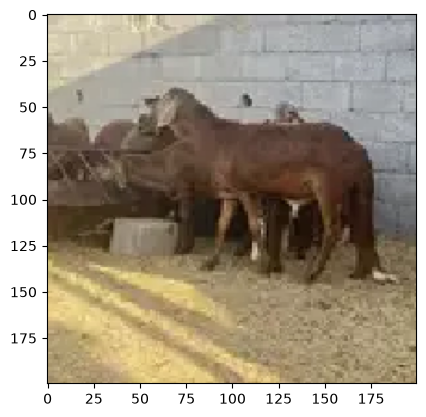

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
This is a: Elephant 🐘


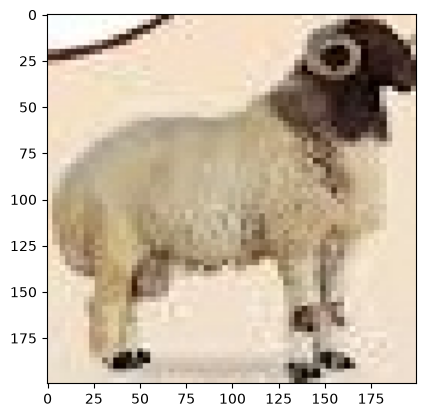

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
This is a: Sheep 🐑


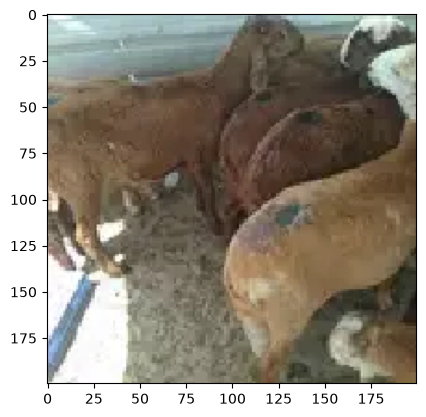

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
This is a: Elephant 🐘


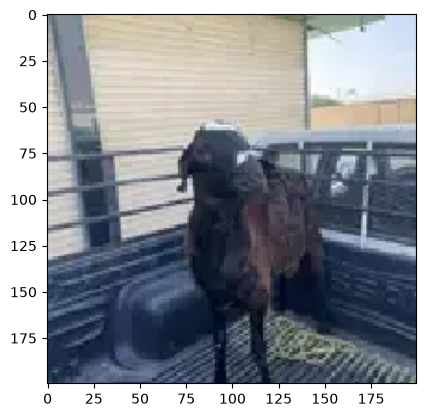

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
This is a: Sheep 🐑


In [74]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# List of classes matching your model's 5 outputs
class_names = ['Cat 🐈', 'Cow 🐄', 'Dog 🐶', 'Elephant 🐘', 'Sheep 🐑']

# Folder path containing test images
dir_path = 'Dataset/test'

# Loop through all files in the folder (including subfolders)
for root, dirs, files in os.walk(dir_path):
    for file in files:
        # Step 1: Get full file path
        img_path = os.path.join(root, file)
        
        # Step 2: Load and show image
        img = image.load_img(img_path, target_size=(200, 200))
        plt.imshow(img)
        plt.show()
        
        # Step 3: Convert image to array & normalize pixels (0 to 1)
        X = image.img_to_array(img) / 255.0
        X = np.expand_dims(X, axis=0)  # Shape: (1, 200, 200, 3)
        
        # Step 4: Predict
        predictions = model.predict(X)
        
        # Step 5: Find class with highest score
        class_index = np.argmax(predictions[0])
        result = class_names[class_index]
        
        print("This is a:", result)

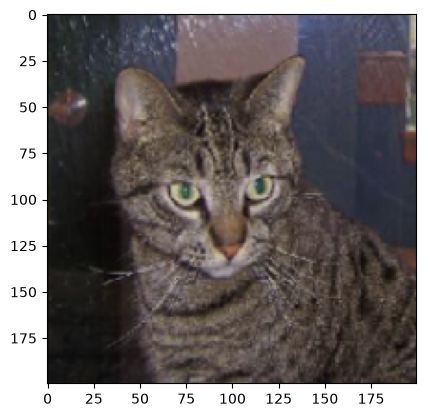

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
96.0% is Cat 🐈


In [ ]:
# 1. Class mapping
class_names = ['Cat 🐈', 'Cow 🐄', 'Dog 🐶', 'Elephant 🐘', 'Sheep 🐑']

# 2. Load and show image
path = "Dataset/test/1.JPG"
img = image.load_img(path, target_size=(200, 200))
plt.imshow(img)
plt.show()

# 3. Prepare image (convert to array & scale pixels 0-1)
X = image.img_to_array(img) / 255.0
X = np.expand_dims(X, axis=0)  # Shape becomes (1, 200, 200, 3)

# 4. Predict class and confidence
predictions = model.predict(X)
class_index = np.argmax(predictions[0])
result = class_names[class_index]

print(f"{round(accuracy * 100, 2)}%","is" , result)

In [94]:
from tensorflow.keras.models import load_model
new_model = load_model('models/CNN_predict_model.h5')

In [97]:
new_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,391 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

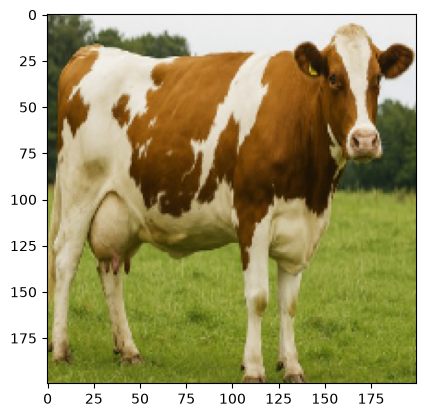

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
96.80999755859375% is Cow 🐄


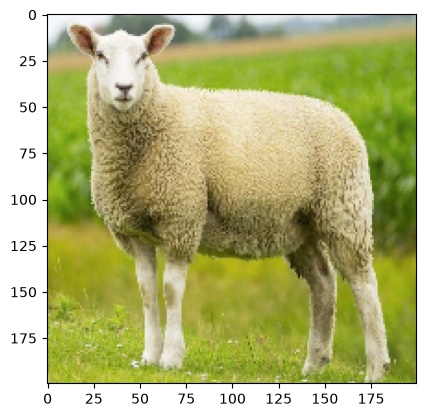

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
99.72000122070312% is Sheep 🐑


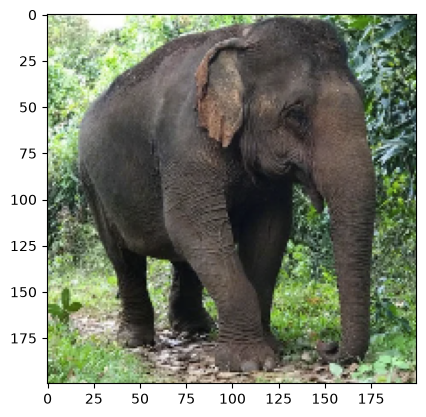

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
99.93000030517578% is Elephant 🐘


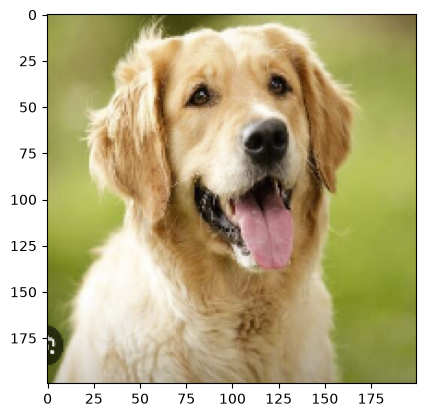

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
99.9800033569336% is Dog 🐶


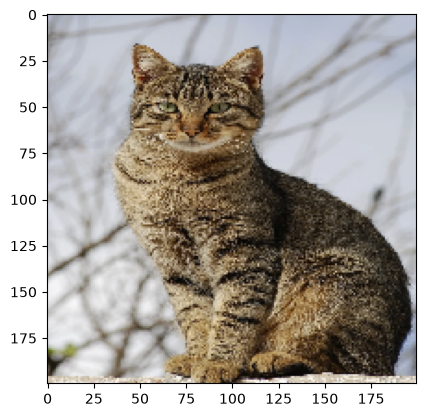

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
99.5999984741211% is Cat 🐈


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# 1. Class mapping
class_names = ['Cat 🐈', 'Cow 🐄', 'Dog 🐶', 'Elephant 🐘', 'Sheep 🐑']

# Loop through all 5 images
for i in range(1, 6):
    # Updated path structure based on your new code
    path = f"Dataset/test/test_sample ({i}).JPG"
    
    # 2. Load and show image
    img = image.load_img(path, target_size=(200, 200))
    plt.imshow(img)
    plt.show()

    # 3. Prepare image (convert to array & scale pixels 0-1)
    X = image.img_to_array(img) / 255.0
    X = np.expand_dims(X, axis=0)  # Shape becomes (1, 200, 200, 3)

    # 4. Predict class and confidence
    # (Leaving verbose=1 default so it outputs the '1/1 ------ 2s 2s/step' line)
    predictions = model.predict(X)
    
    class_index = np.argmax(predictions[0])
    result = class_names[class_index]
    
    # Extract the highest confidence score from the predictions array
    confidence = predictions[0][class_index]

    # Fixed: Replaced the undefined 'accuracy' variable with 'confidence'
    print(f"{round(confidence * 100, 2)}%","is" , result)